# Post-Experiment Analysis & High-Res Visualizations

Notebook takes data already extracted from the identification and ablation passes and generates visualizations. (Basically a dedicated notebook for analysis and graphing)

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import math
from collections import Counter

### 1. Configuration & Constants
Point `BASE_DIR` to the specific run directory you want to analyze.

In [ ]:
# --- CONFIGURATION ---
EXTRACTION_RUN = "llama3-8B_instruct_run_2026-03-07_23-38-50"
RANKING_RUN = "rank_2026-03-10_14-00" # Update to your actual ranking run timestamp
ABLATION_RUN = "ablation_2026-03-10_15-00" # Update to your actual ablation run timestamp

RAW_OUTPUT_DIR = f"../../../../data/retrieval_heads/01_extractions/{EXTRACTION_RUN}/raw_tensors"
RANKING_DIR = f"../../../../data/retrieval_heads/02_rankings/{RANKING_RUN}"
ABLATION_DIR = f"../../../../data/retrieval_heads/03_ablations/{ABLATION_RUN}"
ANALYSIS_OUTPUT_DIR = f"../../../../data/retrieval_heads/04_analysis_plots/plots_for_{ABLATION_RUN}" # Centralized plots folder


os.makedirs(ANALYSIS_OUTPUT_DIR, exist_ok=True) 


SOURCE_MODEL = ""
try:
    with open(os.path.join(ABLATION_DIR, "meta.json"), "r") as f:
        meta_data = json.load(f)
        SOURCE_MODEL = meta_data.get("source_model", "")
except Exception as e:
    pass

model_title_suffix = f" ({SOURCE_MODEL})" if SOURCE_MODEL else ""

print(f"Reading Extractions from: {RAW_OUTPUT_DIR}")
print(f"Reading Rankings from: {RANKING_DIR}")
print(f"Reading Ablations from: {ABLATION_DIR}")
print(f"Saving High-res analysis plots to: {ANALYSIS_OUTPUT_DIR}")


High-res analysis plots will be saved to: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots


### Identification Graphs (High Resolution)

In [3]:
# Load Identification Data
heads_json_path = os.path.join(RANKING_DIR, "ranked_heads.json")
try:
    with open(heads_json_path, "r") as f:
        heads_data = json.load(f)
    
    task_top_heads = heads_data["tasks"]
    shared_heads = heads_data["shared_heads"]
    global_heads = heads_data["global_heads"]
    
    # Load raw NumPy arrays to recreate the heatmaps
    task_mean_scores = {}
    for task_id in task_top_heads.keys():
        files = [f for f in os.listdir(RAW_OUTPUT_DIR) if f.endswith(f"_{task_id}.npy")]
        if files:
            stacked = np.stack([np.load(os.path.join(RAW_OUTPUT_DIR, f)) for f in files])
            task_mean_scores[task_id] = stacked.mean(axis=0)
            
    print(f"Loaded {len(task_mean_scores)} task matrices.")
    print(f"Loaded {len(shared_heads)} shared heads.")
    
except FileNotFoundError:
    print(f"Could not find {heads_json_path}. Make sure the paths are correct.")

Loaded 9 task matrices.
Loaded 7 shared heads.


In [ ]:
# Enlarged Per-Task Heatmaps
for task_id, mean_scores in task_mean_scores.items():
    fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
    im = ax.imshow(mean_scores, aspect="equal", cmap="viridis")

    ax.set_title(f"Sum Attention Scores — {task_id} ({model_title_suffix})", fontsize=24, fontweight='bold', pad=20)
    ax.set_xlabel("Head Index", fontsize=18, fontweight='bold', labelpad=10)
    ax.set_ylabel("Layer Index", fontsize=18, fontweight='bold', labelpad=10)
    
    ax.set_xticks(np.arange(mean_scores.shape[1]))
    ax.set_yticks(np.arange(mean_scores.shape[0]))
    ax.tick_params(axis='both', which='major', labelsize=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Mean Sum Attention", size=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)

    # Red plus markers for the top heads
    for h in task_top_heads[task_id]:
        ax.plot(h["head"], h["layer"], "r+", markersize=14, markeredgewidth=3)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, f"heatmap_{task_id}_large.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.close() # Close to prevent huge inline displays if running locally
    print(f"Saved: {fig_path}")


Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_registrant_name_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_headquarters_city_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_headquarters_state_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_incorporation_state_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_incorporation_year_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_employees_count_total_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\heatmap_holder_record_amount_large.png
Saved: ../../../../data/retrieval_heads/llama3-8B_ins

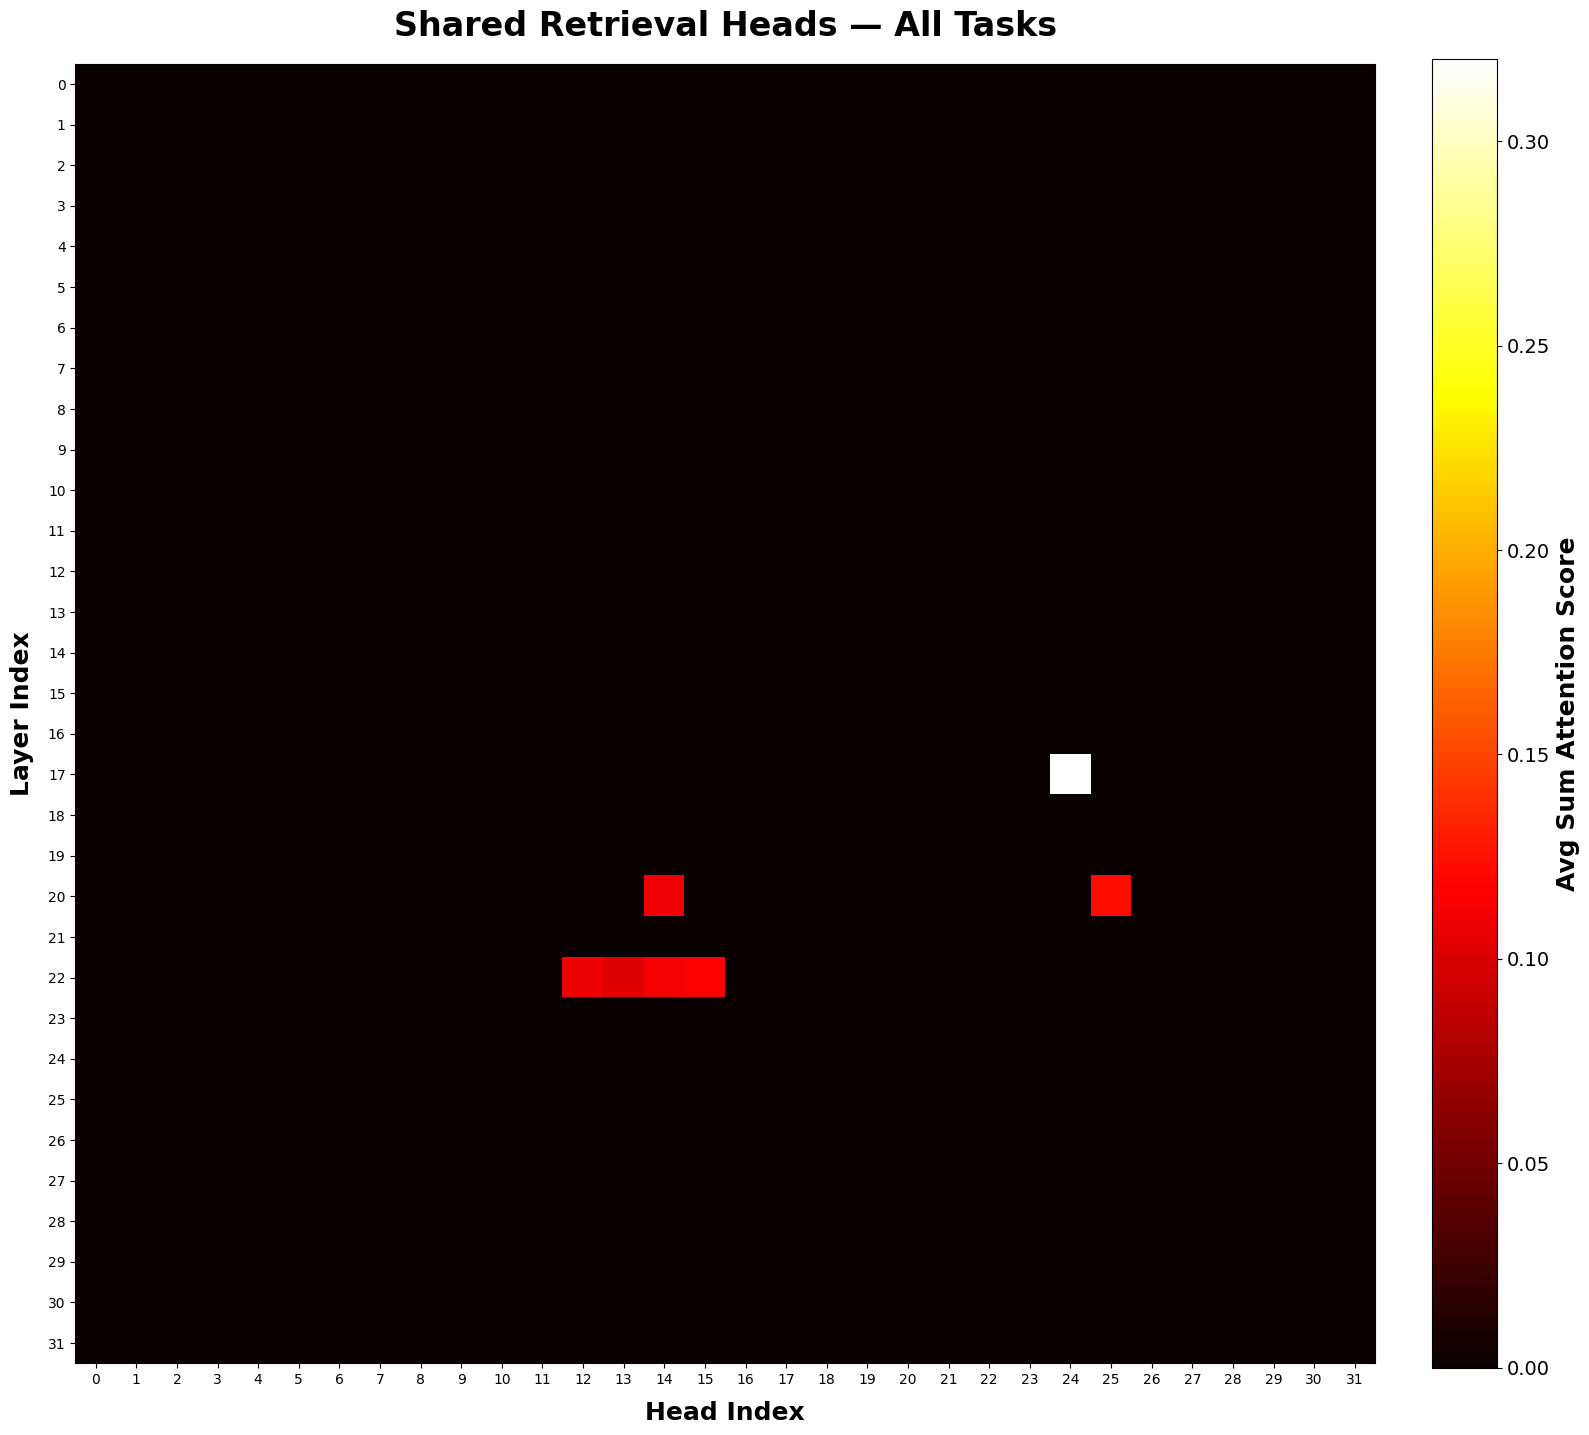

Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\shared_retrieval_heads_large.png


In [ ]:
# Enlarged Shared Heads Grid
if shared_heads:
    sample_shape = next(iter(task_mean_scores.values())).shape
    num_layers, num_heads = sample_shape
    grid = np.zeros((num_layers, num_heads))
    
    for h in shared_heads:
        grid[h["layer"], h["head"]] = h["avg_score"]

    fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
    im = ax.imshow(grid, aspect="equal", cmap="hot")
    
    ax.set_title(f"Shared Retrieval Heads — All Tasks ({model_title_suffix})", fontsize=24, fontweight='bold', pad=20)
    ax.set_xlabel("Head Index", fontsize=18, fontweight='bold', labelpad=10)
    ax.set_ylabel("Layer Index", fontsize=18, fontweight='bold', labelpad=10)
    
    ax.set_xticks(np.arange(num_heads))
    ax.set_yticks(np.arange(num_layers))
    ax.tick_params(axis='both', which='major', labelsize=10)

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Avg Sum Attention Score", size=18, weight='bold')
    cbar.ax.tick_params(labelsize=14)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "shared_retrieval_heads_large.png")
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fig_path}")


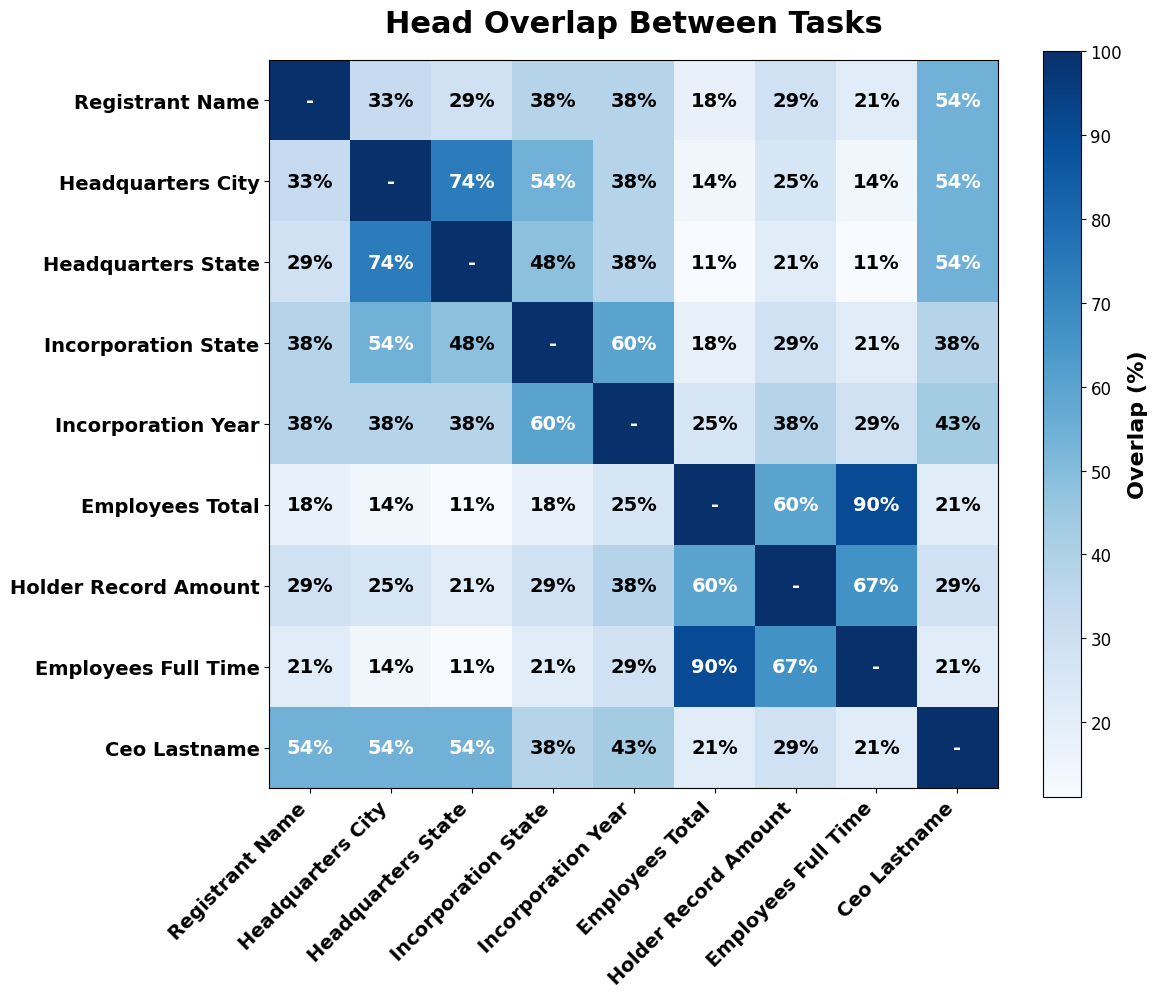

Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\task_overlap_heatmap_large.png


In [ ]:
# Enlarged Task Overlap Heatmap
task_ids = list(task_top_heads.keys())
n_tasks = len(task_ids)
overlap_matrix = np.zeros((n_tasks, n_tasks))

for i, t1 in enumerate(task_ids):
    set1 = set((h["layer"], h["head"]) for h in task_top_heads[t1])
    for j, t2 in enumerate(task_ids):
        set2 = set((h["layer"], h["head"]) for h in task_top_heads[t2])
        union = len(set1 | set2)
        overlap_matrix[i, j] = (len(set1 & set2) / union * 100) if union > 0 else 0

clean_names = [t.replace('_', ' ').title().replace(' Count', '') for t in task_ids]

fig, ax = plt.subplots(figsize=(12, 10), facecolor='white')
cax = ax.imshow(overlap_matrix, cmap='Blues')

cbar = plt.colorbar(cax)
cbar.set_label('Overlap (%)', size=16, weight='bold')
cbar.ax.tick_params(labelsize=12)

ax.set_xticks(np.arange(n_tasks))
ax.set_yticks(np.arange(n_tasks))
ax.set_xticklabels(clean_names, rotation=45, ha='right', fontsize=14, weight='bold')
ax.set_yticklabels(clean_names, fontsize=14, weight='bold')

for i in range(n_tasks):
    for j in range(n_tasks):
        val = overlap_matrix[i, j]
        color = 'white' if val > 50 else 'black'
        text = f"{val:.0f}%" if i != j else "-"
        ax.text(j, i, text, ha='center', va='center', color=color, fontsize=14, weight='bold')

plt.title(f"Head Overlap Between Tasks ({model_title_suffix})", fontsize=22, fontweight='bold', pad=20)
plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "task_overlap_heatmap_large.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved: {fig_path}")


### Space for New/Custom Identification Graphs
Add any new graphs relying solely on the Identification data here.

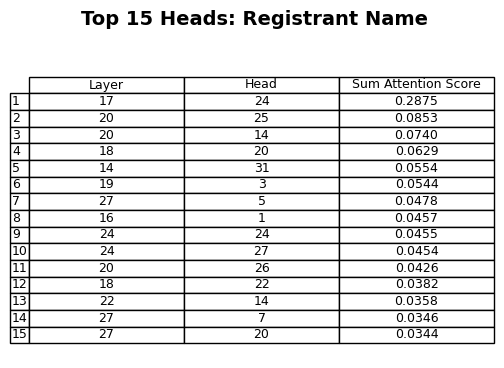

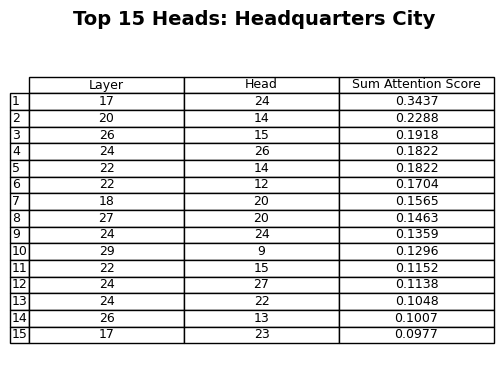

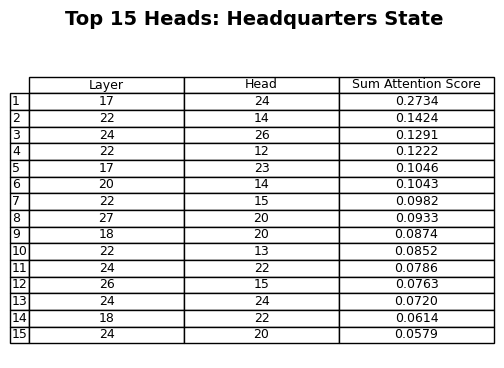

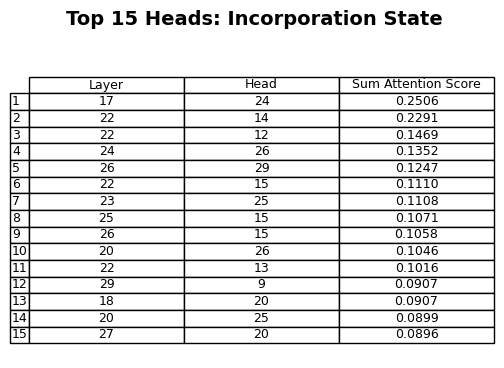

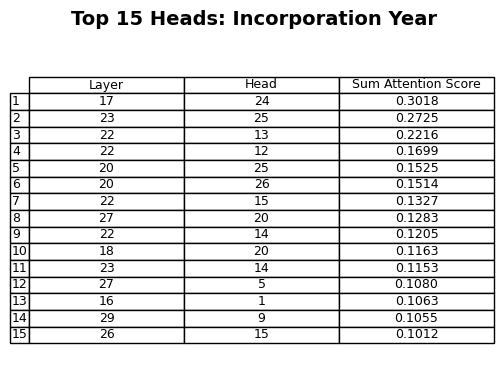

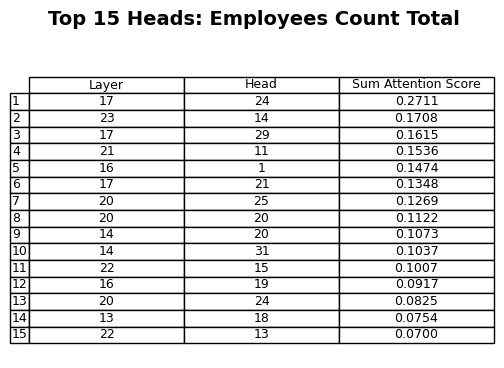

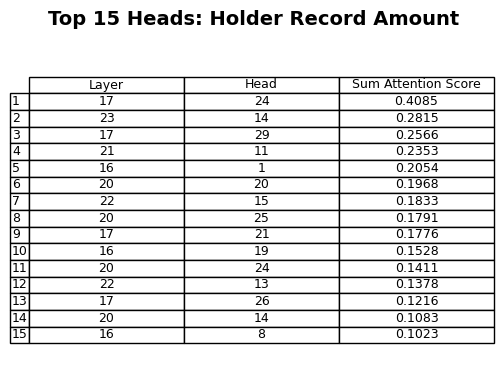

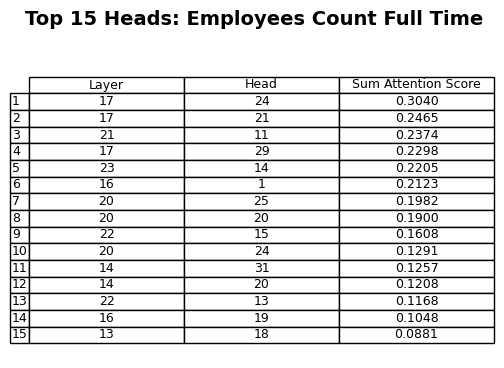

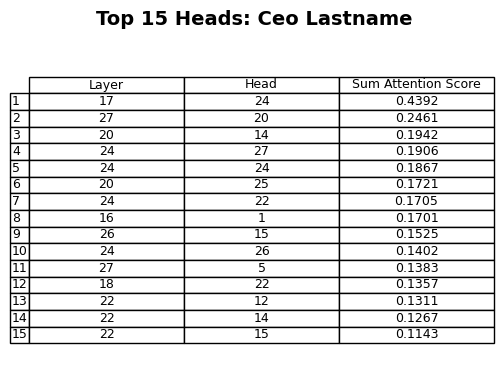

In [ ]:
# Visualize Top 15 Heads per Task as tables
for task_id, heads in task_top_heads.items():
    df_heads = pd.DataFrame(heads[:15]) # Grab top 15
    df_heads['score'] = df_heads['score'].apply(lambda x: f"{x:.4f}")
    df_heads.columns = ['Layer', 'Head', 'Sum Attention Score']
    df_heads.index += 1 # 1-based indexing for display
    
    fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
    fig.subplots_adjust(top=0.85)

    ax.axis('off')
    ax.axis('tight')

    table = ax.table(
        cellText=df_heads.values,
        colLabels=df_heads.columns,
        rowLabels=df_heads.index,
        loc='center',
        cellLoc='center'
    )

    fig.suptitle(
        f"Top 15 Heads: {task_id.replace('_', ' ').title()} ({model_title_suffix})",
        fontsize=14,
        fontweight='bold'
    )
    
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, f"top_heads_table_{task_id}.png")
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
# Global Heads Heatmap
sample_shape = next(iter(task_mean_scores.values())).shape
num_layers, num_heads_count = sample_shape
grid = np.zeros((num_layers, num_heads_count))

for h in global_heads:
    grid[h["layer"], h["head"]] = h["score"]

fig, ax = plt.subplots(figsize=(16, 16), facecolor='white')
im = ax.imshow(grid, aspect="equal", cmap="hot")

ax.set_title(f"Global Retrieval Heads — All Documents ({model_title_suffix})", fontsize=24, fontweight='bold', pad=20)
ax.set_xlabel("Head Index", fontsize=18, fontweight='bold', labelpad=10)
ax.set_ylabel("Layer Index", fontsize=18, fontweight='bold', labelpad=10)

ax.set_xticks(np.arange(num_heads_count))
ax.set_yticks(np.arange(num_layers))
ax.tick_params(axis='both', which='major', labelsize=10)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Avg Sum Attention Score", size=18, weight='bold')
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "global_retrieval_heads_large.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


In [ ]:
# Top 15 Global Heads table
df_global = pd.DataFrame(global_heads[:15])
df_global['score'] = df_global['score'].apply(lambda x: f"{x:.4f}")
df_global.columns = ['Layer', 'Head', 'Sum Attention Score']
df_global.index += 1  # 1-based indexing for display

fig, ax = plt.subplots(figsize=(6, 4), facecolor='white')
fig.subplots_adjust(top=0.85)

ax.axis('off')
ax.axis('tight')

table = ax.table(
    cellText=df_global.values,
    colLabels=df_global.columns,
    rowLabels=df_global.index,
    loc='center',
    cellLoc='center'
)

fig.suptitle(
    f"Top 15 Global Heads ({model_title_suffix})",
    fontsize=14,
    fontweight='bold'
)

fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "top_global_heads_table.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


### Ablation Graphs (High Resolution)
Ensure you have run the `retrieval_head_ablation.ipynb` notebook and saved the JSON files first.

In [ ]:
# Load Ablation Data
try:
    with open(os.path.join(ABLATION_DIR, "baseline_results.json"), "r") as f:
        baseline_results = json.load(f)

    with open(os.path.join(ABLATION_DIR, "within_task_ablation.json"), "r") as f:
        within_task_results = json.load(f)

    with open(os.path.join(ABLATION_DIR, "across_task_ablation.json"), "r") as f:
        across_task_results = json.load(f)

    with open(os.path.join(ABLATION_DIR, "random_ablation_control.json"), "r") as f:
        random_ablation_results = json.load(f)

    baseline_overall = sum(r["matches"] for r in baseline_results.values()) / max(1, sum(r["attempts"] for r in baseline_results.values()))
    print(f"Loaded ablation data. Baseline overall: {baseline_overall:.1%}")
except FileNotFoundError as e:
    print(f"Error loading ablation data: {e}")
    print("Make sure you have run the ablation experiments and saved the JSON results.")

global_task_results = {}
try:
    with open(os.path.join(ABLATION_DIR, "global_ablation.json"), "r") as f:
        global_task_results = json.load(f)
    print(f"Loaded global ablation data ({len(global_task_results)} K values).")
except FileNotFoundError:
    print("global_ablation.json not found — global ablation graph will be skipped.")


Loaded ablation data. Baseline overall: 67.8%


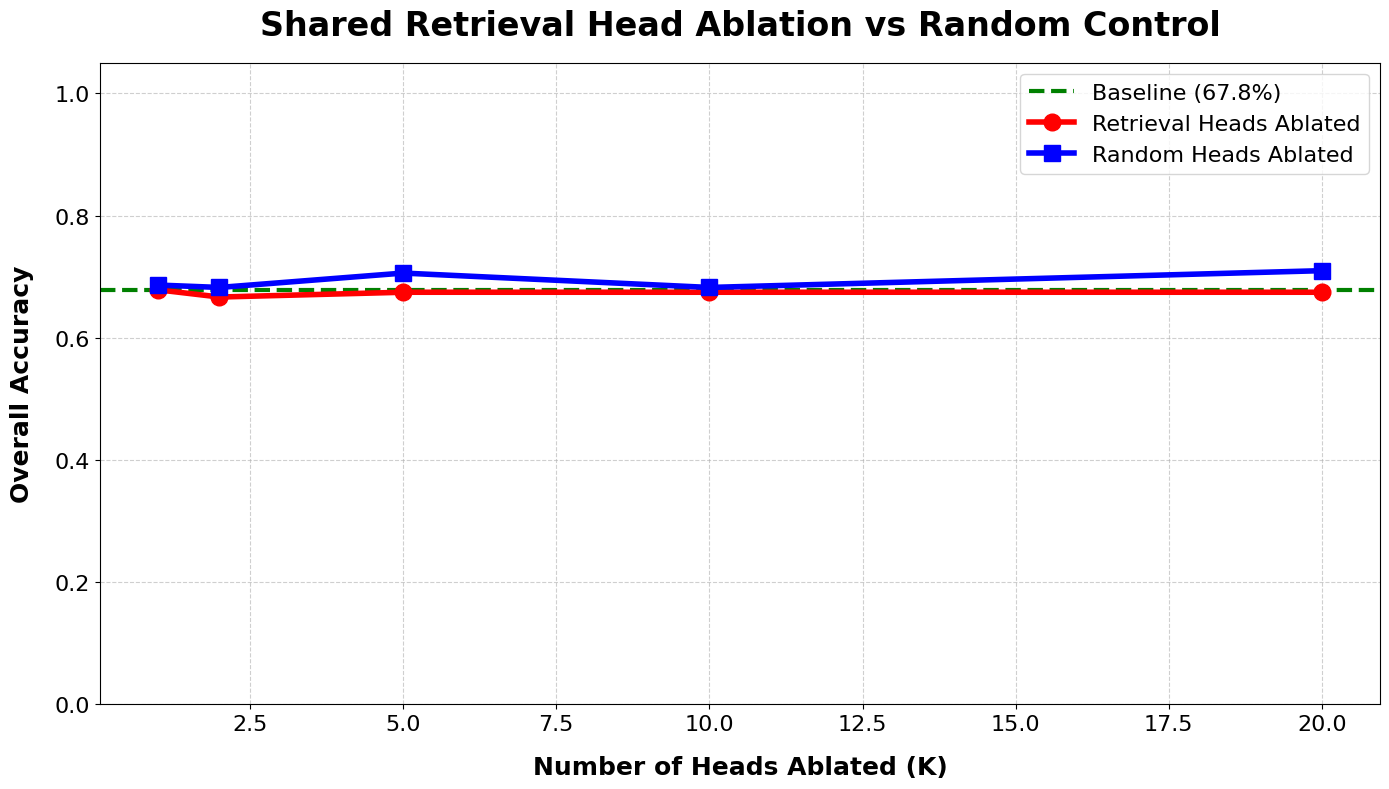

Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\across_task_vs_random_large.png


In [ ]:
# Enlarged Across-task vs Random Ablation
fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')

# Ensure integer keys for sorting
k_vals = sorted([int(k) for k in across_task_results.keys()])
retrieval_acc = [across_task_results[str(k)]["overall_accuracy"] for k in k_vals]

random_acc = []
if random_ablation_results:
    random_acc = [random_ablation_results[str(k)]["overall_accuracy"] for k in k_vals if str(k) in random_ablation_results]

ax.axhline(y=baseline_overall, color="green", linestyle="--", linewidth=3, label=f"Baseline ({baseline_overall:.1%})")
ax.plot(k_vals, retrieval_acc, "ro-", linewidth=4, markersize=12, label="Retrieval Heads Ablated")

if random_acc:
    ax.plot(k_vals[:len(random_acc)], random_acc, "bs-", linewidth=4, markersize=12, label="Random Heads Ablated")

ax.set_xlabel("Number of Heads Ablated (K)", fontsize=18, fontweight='bold', labelpad=15)
ax.set_ylabel("Overall Accuracy", fontsize=18, fontweight='bold', labelpad=15)
ax.set_title(f"Shared Retrieval Head Ablation vs Random Control ({model_title_suffix})", fontsize=24, fontweight='bold', pad=20)

ax.legend(fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.set_ylim(0, 1.05)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "across_task_vs_random_large.png")
plt.savefig(fig_path, dpi=300)
plt.show()
print(f"Saved: {fig_path}")


In [ ]:
# Global Heads Ablation vs Random Control
if global_task_results:
    fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')

    k_vals_g = sorted([int(k) for k in global_task_results.keys()])
    global_acc = [global_task_results[str(k)]["overall_accuracy"] for k in k_vals_g]

    random_acc_g = []
    if random_ablation_results:
        random_acc_g = [random_ablation_results[str(k)]["overall_accuracy"] for k in k_vals_g if str(k) in random_ablation_results]

    ax.axhline(y=baseline_overall, color="green", linestyle="--", linewidth=3, label=f"Baseline ({baseline_overall:.1%})")
    ax.plot(k_vals_g, global_acc, "ro-", linewidth=4, markersize=12, label="Global Heads Ablated")

    if random_acc_g:
        ax.plot(k_vals_g[:len(random_acc_g)], random_acc_g, "bs-", linewidth=4, markersize=12, label="Random Heads Ablated")

    ax.set_xlabel("Number of Heads Ablated (K)", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_ylabel("Overall Accuracy", fontsize=18, fontweight='bold', labelpad=15)
    ax.set_title(f"Global Retrieval Head Ablation vs Random Control ({model_title_suffix})", fontsize=24, fontweight='bold', pad=20)

    ax.legend(fontsize=16)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "global_ablation_vs_random_large.png")
    plt.savefig(fig_path, dpi=300)
    plt.show()
    print(f"Saved: {fig_path}")
else:
    print("Skipping global ablation graph - no data loaded.")


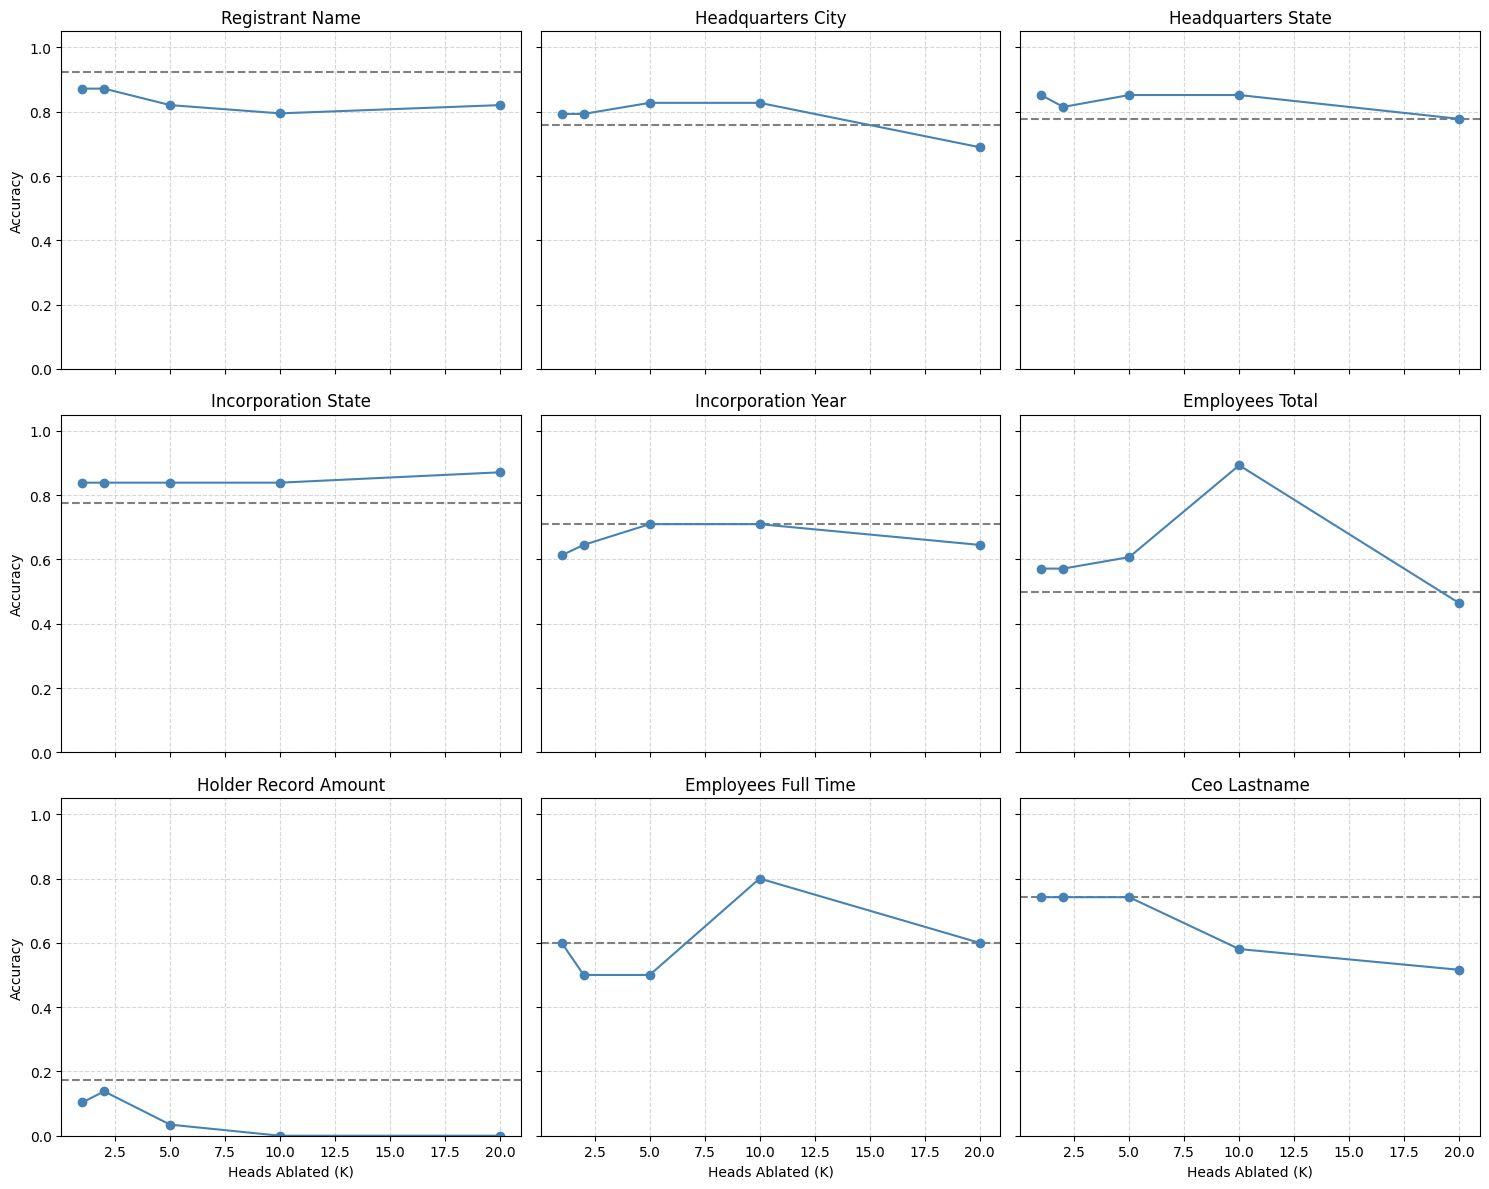

Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\within_task_ablation_grid.png


In [ ]:
n_tasks = len(within_task_results)
cols = 3
rows = math.ceil(n_tasks / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, (task_id, k_results) in enumerate(within_task_results.items()):
    ax = axes[i]
    k_vals = sorted([int(k) for k in k_results.keys()])
    acc_vals = [k_results[str(k)]["accuracy"] for k in k_vals]
    base_acc = baseline_results[task_id]['accuracy']
    
    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
    
    ax.axhline(y=base_acc, color="gray", linestyle="--", label="Baseline")
    ax.plot(k_vals, acc_vals, "o-", color="steelblue", label="Accuracy")
    
    ax.set_title(display_name)
    ax.set_ylim(0, 1.05)
    ax.grid(True, linestyle='--', alpha=0.5)
    if i % cols == 0:
        ax.set_ylabel("Accuracy")
    if i >= n_tasks - cols:
        ax.set_xlabel("Heads Ablated (K)")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(f"Within-Task Ablation ({model_title_suffix})", fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "within_task_ablation_grid.png")
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")


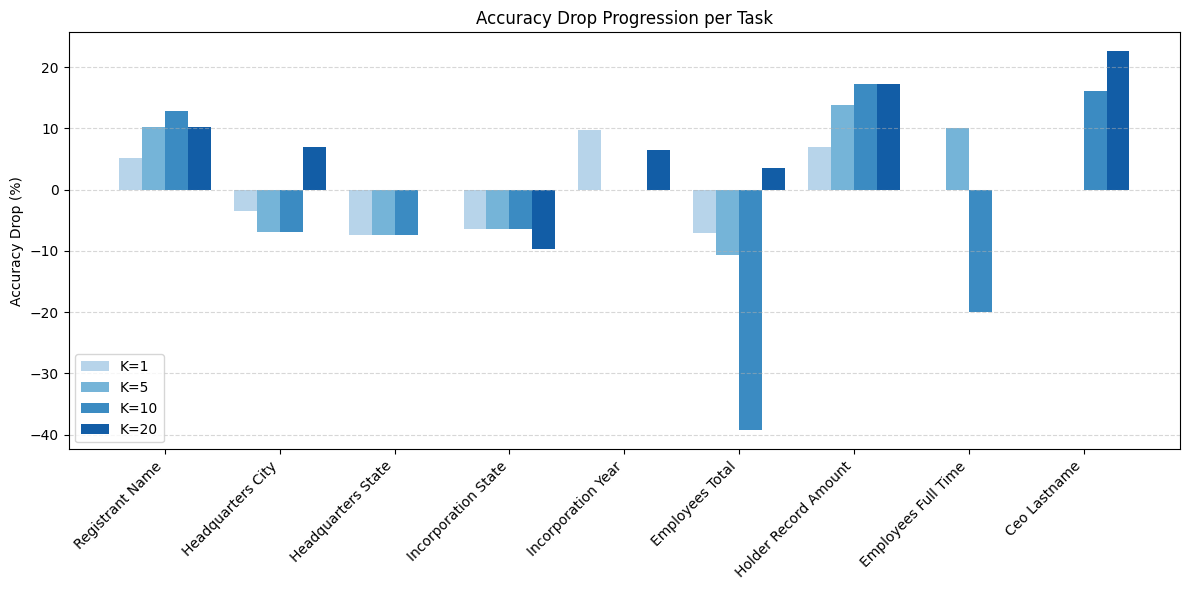

Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\accuracy_drop_progression.png


In [ ]:
k_targets = [1, 5, 10, 20]
x = np.arange(len(within_task_results))
width = 0.8 / len(k_targets)

fig, ax = plt.subplots(figsize=(12, 6))
task_labels = []

for idx, (task_id, results) in enumerate(within_task_results.items()):
    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
    task_labels.append(display_name)
    base_acc = baseline_results[task_id]['accuracy']
    
    for j, k in enumerate(k_targets):
        if str(k) in results:
            drop = (base_acc - results[str(k)]['accuracy']) * 100
            color = plt.cm.Blues(0.3 + j * (0.7 / len(k_targets)))
            ax.bar(idx + j * width - 0.4 + width/2, drop, width, color=color, label=f"K={k}" if idx == 0 else "")

ax.set_ylabel("Accuracy Drop (%)")
ax.set_title(f"Accuracy Drop Progression per Task ({model_title_suffix})")
ax.set_xticks(x)
ax.set_xticklabels(task_labels, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "accuracy_drop_progression.png")
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


### Space for New/Custom Ablation Graphs
Add any new graphs relying solely on the Ablation data here.

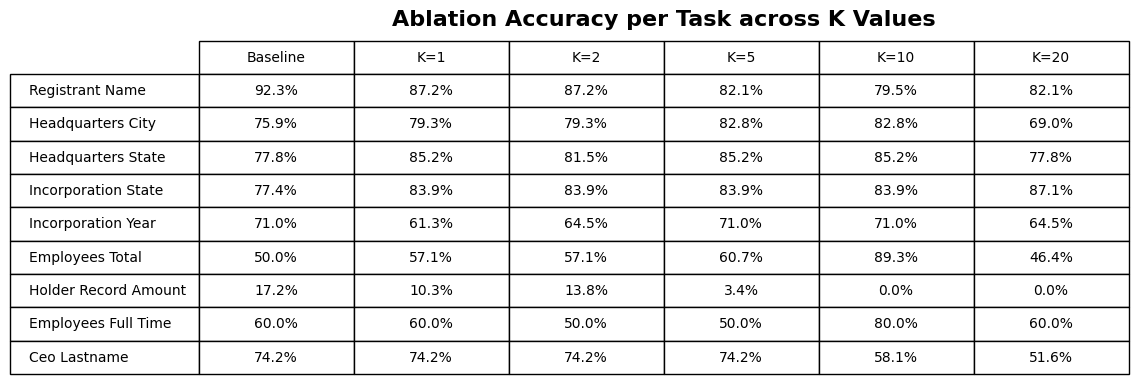

Saved: ../../../../data/retrieval_heads/llama3-8B_instruct_run_2026-03-07_23-38-50\analysis_plots\ablation_accuracy_table.png


In [ ]:
# Visualize ablation accuracy numbers per K round
k_vals = sorted([int(k) for k in next(iter(within_task_results.values())).keys()])
data_rows = []
row_labels = []

for task_id, results in within_task_results.items():
    display_name = clean_names[task_ids.index(task_id)] if task_id in task_ids else task_id
    row_labels.append(display_name)
    row_data = [f"{baseline_results[task_id]['accuracy']:.1%}"]
    
    for k in k_vals:
        if str(k) in results:
            row_data.append(f"{results[str(k)]['accuracy']:.1%}")
        else:
            row_data.append("-")
            
    data_rows.append(row_data)

col_labels = ['Baseline'] + [f"K={k}" for k in k_vals]

fig, ax = plt.subplots(figsize=(12, 4), facecolor='white')
ax.axis('off')
ax.axis('tight')

table = ax.table(cellText=data_rows, colLabels=col_labels, rowLabels=row_labels, loc='center', cellLoc='center')
table.scale(1, 2)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title(f"Ablation Accuracy per Task across K Values ({model_title_suffix})", fontsize=16, fontweight='bold', pad=20)

fig_path = os.path.join(ANALYSIS_OUTPUT_DIR, "ablation_accuracy_table.png")
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")
